**Lizenzhinweise:**  


### WIP! Zitation und Urheber.
**Autor:** 

**Dataset:** FCCU-Dataset (MIT-Lizenz) von Ankur Kumar/ML-PSE. Bitte die CSVs lokal bereitstellen.

**Juypter Notebook:** basierend auf den Jupyter Notebooks von Ankur Kumar unter MIT Lizenz.

**MIT License**  
Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.

---

## FCCU Datensatz – Maschinelles Lernen für Novelty Detection

<div style="border-left: 4px solid #4F81BD; background:#F7FBFF; padding:10px 12px; margin:8px 0;">
<b>Lernziel</b><br>
Dieses Notebook zeigt einen sauberen Baseline-Pfad für die <i>Fehlerdetektion</i> im FCCU-Datensatz:
vom stabilen und variablen Normalbetrieb über dynamische lineare Verfahren bis zu klassischen
Novelty-Detection-Verfahren. Im Mittelpunkt steht nicht die Fault-Diagnose, sondern die möglichst
frühe und zugleich stabile Erkennung einer Abnormalität.
</div>

## Konfiguration

<div style="border-left: 4px solid #4F81BD; background:#F7FBFF; padding:10px 12px; margin:8px 0;">
<b>Hinweis</b><br>
Für die Lehre kann mit <code>NOC_stable</code> begonnen werden. Die realistische Referenz ist
aber <code>NOC_varying</code>. Über den Datei-Block lässt sich das schrittweise zuschalten.
</div>

Im folgenden Block werden Dateipfade, Fensterparameter, Onset-Definition und die Evaluationslogik
gesetzt. Die zeitliche Aufteilung erfolgt <i>vor</i> der Fensterung.

In [5]:
# --- Pfade anpassen ---
DATA_DIR = "./"

FILES = {
    "NOC_stable": f"{DATA_DIR}/NOC_stableFeedFlow_outputs.csv",
#    "NOC_varying": f"{DATA_DIR}/NOC_varyingFeedFlow_outputs.csv",
    "FAULT_UAf": f"{DATA_DIR}/UAf_decrease_outputs.csv",
#    "FAULT_condEff": f"{DATA_DIR}/condEff_decrease_outputs.csv",
#    "FAULT_deltaP": f"{DATA_DIR}/deltaP_increase_outputs.csv",
    "FAULT_sensorDrift": f"{DATA_DIR}/Fhn_sensorDrift_outputs.csv",
#    "FAULT_valveLeak": f"{DATA_DIR}/CAB_valveLeak_outputs.csv",
}

# --- Allgemeine Parameter ---
TIME_COL_CANDIDATES = ["time", "timestamp", "t"]  # mögliche Namen der Zeitspalte
DROP_COLS = []                                    # optional zu entfernende Spalten

WINDOW = 60                                       # Fensterlänge in Samples; bei 1 min Samplezeit = 60 Minuten
HOP = 10                                          # Schrittweite zwischen zwei Fenstern; bei 1 min Samplezeit = 10 Minuten

RANDOM_STATE = 42                                 # Startwert für Zufallszahlen; sorgt für reproduzierbare Ergebnisse
TARGET_FAR = 0.001                                # Zielwert für die False Alarm Rate bei der Schwellenkalibrierung

# Chronologischer Split der NOC-Sequenzen (vor der Fensterung)
NOC_TRAIN_FRAC = 0.50                             # Anteil des Normalbetriebs für das Training
NOC_VAL_FRAC = 0.25                               # Anteil des Normalbetriebs für Validierung und Schwellenkalibrierung
NOC_TEST_FRAC = 0.25                              # Anteil des Normalbetriebs für den abschließenden Test

# Fault-Onset im FCCU-Datensatz
SAMPLE_TIME_MINUTES = 1.0                         # Abtastzeit in Minuten pro Zeitschritt
FAULT_ONSET = 120                                 # Fehlerbeginn bei 120 Minuten
FAULT_ONSET_INDEX = int(FAULT_ONSET / SAMPLE_TIME_MINUTES)   # Fehlerbeginn in Zeitschritt-Index umgerechnet

# Label-Regel für Fault-Fenster:
# "end"    -> Fenster gilt als Fault, sobald das Fensterende nach dem Onset liegt
# "center" -> Fenster gilt als Fault, sobald das Fensterzentrum nach dem Onset liegt
# "start"  -> Fenster gilt als Fault, sobald das Fenster vollständig nach dem Onset beginnt
FAULT_WINDOW_LABEL_RULE = "end"                   # legt fest, ab wann ein Fenster als fault-behaftet markiert wird

# Modellparameter
PCA_VAR_TARGET = 0.9                             # Zielanteil erklärter Varianz für die Auswahl der PCA-Komponenten
MIN_PCA_COMPONENTS = 2                            # minimale Anzahl von Hauptkomponenten für DPCA
MAX_PCA_COMPONENTS = None                         # optionale obere Grenze für die Zahl der DPCA-Komponenten

CVA_LAGS = 10                                     # Anzahl der Vergangenheits-/Zukunftsschritte für CVA
CVA_VAR_TARGET = 0.9                             # Zielanteil der erfassten Dynamik für die Auswahl der CVA-Komponenten
MIN_CVA_COMPONENTS = 2                            # minimale Anzahl von CVA-Komponenten
MAX_CVA_COMPONENTS = None                         # optionale obere Grenze für die Zahl der CVA-Komponenten
CVA_WINDOW_AGG = "mean"                           # Aggregation der zeitschrittweisen CVA-Scores pro Fenster; "mean" mittelt, "max" betont Spitzen

# Alarmmanagement
PERSISTENCE = 3                                   # drei aufeinanderfolgende Überschreitungen sind nötig, bis ein Alarm aktiv wird

print("Konfiguration geladen.")

Konfiguration geladen.


<div style="border-left: 4px solid #A6A6A6; background:#FAFAFA; padding:10px 12px; margin:8px 0;">
<b>Merksatz</b><br>
Der wichtigste methodische Schutz gegen Data Leakage ist hier: zuerst zeitlich splitten, danach fenstern,
standardisieren, modellieren und erst am Schluss bewerten.
</div>

In [7]:
import os
import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import roc_auc_score, average_precision_score

import matplotlib.pyplot as plt

np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------------
# Laden und Vorverarbeitung
# ------------------------------------------------------------------
def _read_csv_safe(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Datei nicht gefunden: {path}")
    df = pd.read_csv(path)
    for c in TIME_COL_CANDIDATES:
        if c in df.columns:
            try:
                df[c] = pd.to_datetime(df[c])
                df = df.sort_values(c).reset_index(drop=True)
                break
            except Exception:
                pass
    return df

def _numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    if DROP_COLS:
        df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    num = df.select_dtypes(include=[np.number]).copy()
    num = num.replace([np.inf, -np.inf], np.nan)
    num = num.dropna(axis=1, how="any")
    return num


def load_fccu_files(files: Dict[str, str]) -> Dict[str, pd.DataFrame]:
    data = {}
    for k, p in files.items():
        try:
            df = _read_csv_safe(p)
            data[k] = _numeric_df(df)
            print(f"✔ Geladen: {k:<18} -> roh {df.shape}, numerisch {data[k].shape}")
        except FileNotFoundError:
            print(f"⚠ Übersprungen (nicht gefunden): {k} -> {p}")
    return data

def align_common_columns(data: Dict[str, pd.DataFrame]) -> Tuple[Dict[str, pd.DataFrame], List[str]]:
    if not data:
        return data, []
    ordered_cols = list(next(iter(data.values())).columns)
    common = set(ordered_cols)
    for df in data.values():
        common &= set(df.columns)
    common_cols = [c for c in ordered_cols if c in common]
    aligned = {k: df[common_cols].copy() for k, df in data.items()}
    return aligned, common_cols

def split_sequence_chronological(
    X: np.ndarray,
    train_frac: float,
    val_frac: float,
    test_frac: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    total = train_frac + val_frac + test_frac
    if not np.isclose(total, 1.0):
        raise ValueError("Die Split-Anteile müssen zusammen 1.0 ergeben.")
    T = len(X)
    i1 = int(np.floor(T * train_frac))
    i2 = int(np.floor(T * (train_frac + val_frac)))
    return X[:i1].copy(), X[i1:i2].copy(), X[i2:].copy()

# Erzeugt Fenster pro Sequenz und schreibt Metadaten wie Start, Ende und Fault-Label mit.
def make_windows_with_meta(
    X: np.ndarray,
    window: int,
    hop: int,
    source: str,
    split_name: str,
    onset_idx: Optional[int] = None,
    label_rule: str = "end",
) -> Tuple[np.ndarray, pd.DataFrame]:
    T, D = X.shape
    if T < window:
        meta = pd.DataFrame(columns=[
            "source", "split", "start", "end", "center", "y",
            "onset_idx", "is_fault_sequence", "post_onset"
        ])
        return np.empty((0, window * D)), meta

    starts = list(range(0, T - window + 1, hop))
    out = np.empty((len(starts), window * D), dtype=float)
    rows = []

    for i, s in enumerate(starts):
        e = s + window
        c = s + window // 2
        out[i] = X[s:e, :].reshape(-1)

        y = 0
        post_onset = False
        if onset_idx is not None:
            if label_rule == "start":
                post_onset = s >= onset_idx
            elif label_rule == "center":
                post_onset = c >= onset_idx
            else:
                post_onset = e > onset_idx
            y = int(post_onset)

        rows.append({
            "source": source,
            "split": split_name,
            "start": s,
            "end": e,
            "center": c,
            "y": y,
            "onset_idx": onset_idx,
            "is_fault_sequence": int(onset_idx is not None),
            "post_onset": int(post_onset),
        })

    meta = pd.DataFrame(rows)
    return out, meta

# Fasst mehrere Fensterblöcke aus verschiedenen Läufen zu einem gemeinsamen Datensatz zusammen.
def combine_window_blocks(blocks: List[Tuple[np.ndarray, pd.DataFrame]]) -> Tuple[np.ndarray, pd.DataFrame]:
    Xs, metas = [], []
    for Xb, mb in blocks:
        if len(Xb) == 0:
            continue
        Xs.append(Xb)
        metas.append(mb)
    if not Xs:
        return np.empty((0, 0)), pd.DataFrame()
    X = np.vstack(Xs)
    meta = pd.concat(metas, axis=0, ignore_index=True)
    meta["global_idx"] = np.arange(len(meta))
    return X, meta

# Standardisierung nur auf den Trainingsfenstern des Normalbetriebs.
def fit_window_scaler(X_train: np.ndarray) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(X_train)
    return scaler

def transform_with_scaler(scaler: StandardScaler, X: np.ndarray) -> np.ndarray:
    if X.size == 0:
        return X.copy()
    return scaler.transform(X)

# Standardisierung der Rohsequenzen für CVA auf Basis des Trainings-Normalbetriebs.
def fit_raw_scaler(sequence_map: Dict[str, np.ndarray]) -> StandardScaler:
    mats = [arr for arr in sequence_map.values() if len(arr) > 0]
    if not mats:
        raise ValueError("Keine Rohsequenzen zum Fitten des Scalers vorhanden.")
    scaler = StandardScaler()
    scaler.fit(np.vstack(mats))
    return scaler

def transform_sequence_map(scaler: StandardScaler, sequence_map: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    return {k: scaler.transform(v) if len(v) > 0 else v.copy() for k, v in sequence_map.items()}

# ------------------------------------------------------------------
# DPCA
# ------------------------------------------------------------------
# Auswahl und Auswertung eines PCA-Modells auf den gefensterten Daten,
# damit zeitlich erweiterte Zustände als dynamische Baseline überwacht werden können.

def select_pca_components(
    X_train: np.ndarray,
    var_target: float = 0.95,
    min_components: int = 2,
    max_components: Optional[int] = None,
) -> int:
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X_train)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n = int(np.searchsorted(cum, var_target) + 1)
    n = max(min_components, n)
    n = min(n, X_train.shape[1], X_train.shape[0])
    if max_components is not None:
        n = min(n, int(max_components))
    return max(1, n)

# Fit des DPCA-Modells und Berechnung der Trainingsreferenz für T² und SPE.
def fit_dpca_model(
    X_train: np.ndarray,
    var_target: float = 0.95,
    min_components: int = 2,
    max_components: Optional[int] = None,
) -> dict:
    n_components = select_pca_components(
        X_train,
        var_target=var_target,
        min_components=min_components,
        max_components=max_components,
    )
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    Ztr = pca.fit_transform(X_train)
    T2_tr = np.sum((Ztr ** 2) / (pca.explained_variance_ + 1e-12), axis=1)
    Xtr_hat = pca.inverse_transform(Ztr)
    SPE_tr = np.sum((X_train - Xtr_hat) ** 2, axis=1)

    return {
        "pca": pca,
        "median_t2": float(np.median(T2_tr)),
        "median_spe": float(np.median(SPE_tr)),
        "n_components": n_components,
        "explained_variance_sum": float(np.sum(pca.explained_variance_ratio_)),
        "train_score": (T2_tr / (np.median(T2_tr) + 1e-9)) + (SPE_tr / (np.median(SPE_tr) + 1e-9)),
    }

# Anwendung des gefitteten DPCA-Modells auf neue Fenster.
def score_dpca_model(model: dict, X_new: np.ndarray) -> np.ndarray:
    pca = model["pca"]
    Znew = pca.transform(X_new)
    T2_new = np.sum((Znew ** 2) / (pca.explained_variance_ + 1e-12), axis=1)
    Xnew_hat = pca.inverse_transform(Znew)
    SPE_new = np.sum((X_new - Xnew_hat) ** 2, axis=1)
    return (T2_new / (model["median_t2"] + 1e-9)) + (SPE_new / (model["median_spe"] + 1e-9))

# ------------------------------------------------------------------
# CVA
# ------------------------------------------------------------------
# CVA modelliert die Beziehung zwischen Vergangenheit und Zukunft einer Zeitreihe,
# um dynamische Zustände expliziter als bei einer reinen PCA abzubilden.

def _inv_sqrtm_psd(S: np.ndarray, reg: float = 1e-6) -> np.ndarray:
    vals, vecs = np.linalg.eigh(S)
    vals = np.clip(vals, reg, None)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def build_past_future_blocks(X: np.ndarray, lags: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    T, D = X.shape
    if T < 2 * lags + 1:
        return np.empty((0, lags * D)), np.empty((0, lags * D)), np.empty((0,), dtype=int)

    P, F, times = [], [], []
    for t in range(lags, T - lags + 1):
        past = X[t - lags:t, :].reshape(-1)
        future = X[t:t + lags, :].reshape(-1)
        P.append(past)
        F.append(future)
        times.append(t)
    return np.asarray(P), np.asarray(F), np.asarray(times, dtype=int)

# Fit des CVA-Modells auf den Trainingssequenzen des Normalbetriebs.
def fit_cva(
    train_sequences: Dict[str, np.ndarray],
    lags: int = 10,
    var_target: float = 0.95,
    min_components: int = 2,
    max_components: Optional[int] = None,
    reg: float = 1e-6,
) -> dict:
    P_list, F_list = [], []
    for X in train_sequences.values():
        P, F, _ = build_past_future_blocks(X, lags)
        if len(P) > 0:
            P_list.append(P)
            F_list.append(F)

    if not P_list:
        raise ValueError("CVA kann nicht gefittet werden: Sequenzen sind zu kurz oder fehlen.")

    P_all = np.vstack(P_list)
    F_all = np.vstack(F_list)

    mu_p = P_all.mean(axis=0)
    mu_f = F_all.mean(axis=0)
    P0 = P_all - mu_p
    F0 = F_all - mu_f

    n = P0.shape[0]
    Sxx = (P0.T @ P0) / max(n - 1, 1) + reg * np.eye(P0.shape[1])
    Syy = (F0.T @ F0) / max(n - 1, 1) + reg * np.eye(F0.shape[1])
    Sxy = (P0.T @ F0) / max(n - 1, 1)

    Wx = _inv_sqrtm_psd(Sxx, reg=reg)
    Wy = _inv_sqrtm_psd(Syy, reg=reg)

    C = Wx @ Sxy @ Wy
    U, s, Vt = np.linalg.svd(C, full_matrices=False)

    energy = np.cumsum(s ** 2) / (np.sum(s ** 2) + 1e-12)
    r = int(np.searchsorted(energy, var_target) + 1)
    r = max(min_components, r)
    if max_components is not None:
        r = min(r, int(max_components))
    r = min(r, len(s))

    model = {
        "lags": lags,
        "mu_p": mu_p,
        "mu_f": mu_f,
        "Wx": Wx,
        "Wy": Wy,
        "U": U[:, :r],
        "V": Vt.T[:, :r],
        "s": s[:r],
        "n_components": r,
        "energy": float(energy[r - 1]),
    }
    return model

def cva_sequence_scores(model: dict, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    P, F, times = build_past_future_blocks(X, model["lags"])
    if len(P) == 0:
        return np.empty((0,), dtype=int), np.empty((0,), dtype=float)

    P0 = P - model["mu_p"]
    F0 = F - model["mu_f"]

    Pw = P0 @ model["Wx"].T
    Fw = F0 @ model["Wy"].T

    Z = Pw @ model["U"]
    Fw_hat = Z @ np.diag(model["s"]) @ model["V"].T
    residual = Fw - Fw_hat
    scores = np.sum(residual ** 2, axis=1)
    return times, scores

def aggregate_time_scores_to_windows(
    times: np.ndarray,
    scores_t: np.ndarray,
    meta_seq: pd.DataFrame,
    agg: str = "mean",
) -> np.ndarray:
    out = np.full(len(meta_seq), np.nan, dtype=float)
    for idx, row in meta_seq.reset_index(drop=True).iterrows():
        mask = (times >= int(row["start"])) & (times < int(row["end"]))
        vals = scores_t[mask]
        if vals.size == 0:
            continue
        if agg == "max":
            out[idx] = float(np.max(vals))
        else:
            out[idx] = float(np.mean(vals))
    return out

# Ordnet die CVA-Zeitschrittscores wieder den Fenstern zu.
def cva_scores_for_meta(
    model: dict,
    scaled_sequences: Dict[str, np.ndarray],
    meta_df: pd.DataFrame,
    agg: str = "mean",
) -> np.ndarray:
    out = np.full(len(meta_df), np.nan, dtype=float)
    if meta_df.empty:
        return out

    for source, idx in meta_df.groupby("source").groups.items():
        seq = scaled_sequences[source]
        times, scores_t = cva_sequence_scores(model, seq)
        meta_seq = meta_df.loc[list(idx)].copy().reset_index(drop=True)
        vals = aggregate_time_scores_to_windows(times, scores_t, meta_seq, agg=agg)
        out[list(idx)] = vals

    if np.any(np.isnan(out)):
        fill_val = np.nanmedian(out[np.isfinite(out)]) if np.any(np.isfinite(out)) else 0.0
        out = np.where(np.isfinite(out), out, fill_val)
    return out

# ------------------------------------------------------------------
# Klassische Novelty Detection / Autoencoder
# ------------------------------------------------------------------
# Diese Modelle arbeiten auf den gefensterten Merkmalen und dienen als Vergleich
# zu den linearen dynamischen Verfahren DPCA und CVA.

# Fit klassischer One-Class-Modelle auf Normaldaten.
def fit_oneclass_models(X_train: np.ndarray) -> Dict[str, object]:
    models = {}

    iforest = IsolationForest(
        n_estimators=300,
        contamination="auto",
        random_state=RANDOM_STATE,
    )
    iforest.fit(X_train)
    models["isoforest"] = iforest

    oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
    oc.fit(X_train)
    models["ocsvm"] = oc

    lof = LocalOutlierFactor(n_neighbors=35, novelty=True)
    lof.fit(X_train)
    models["lof"] = lof
    return models

def score_oneclass_models(models: Dict[str, object], X_new: np.ndarray) -> Dict[str, np.ndarray]:
    out = {}
    out["isoforest"] = -models["isoforest"].score_samples(X_new)
    out["ocsvm"] = -models["ocsvm"].decision_function(X_new).ravel()
    out["lof"] = -models["lof"].decision_function(X_new).ravel()
    return out

# Kompakter Autoencoder als Ausblick auf rekonstruktionsbasierte Deep-Learning-Modelle.
def fit_shallow_autoencoder(
    X_train: np.ndarray,
    hidden_ratio: float = 0.5,
    max_iter: int = 200,
) -> MLPRegressor:
    d = X_train.shape[1]
    h = max(4, int(d * hidden_ratio))
    ae = MLPRegressor(
        hidden_layer_sizes=(h,),
        activation="relu",
        solver="adam",
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    ae.fit(X_train, X_train)
    return ae

def score_shallow_autoencoder(ae: MLPRegressor, X_new: np.ndarray) -> np.ndarray:
    new_hat = ae.predict(X_new)
    return np.sum((X_new - new_hat) ** 2, axis=1)


# ------------------------------------------------------------------
# Plotting und globale Kennzahlen
# ------------------------------------------------------------------
def eval_scores(y_true: np.ndarray, score: np.ndarray, title: str = "") -> dict:
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)

    auc = np.nan
    ap = np.nan
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, score)
        ap = average_precision_score(y_true, score)

    print(f"{title:<24} -> ROC-AUC={auc:.3f} | AP={ap:.3f}")
    return {"roc_auc": auc, "ap": ap}

# Einfache Übersichtsgrafik für den Score-Verlauf über NOC- und Fault-Fenster.
def plot_score_timeline(
    scores: np.ndarray,
    meta_df: pd.DataFrame,
    title: str,
    ylabel: str = "Score",
) -> None:
    if meta_df.empty:
        print(f"Keine Daten zum Plotten für: {title}")
        return

    xs = np.arange(len(scores))
    fig = plt.figure(figsize=(12, 3.5))
    ax = plt.gca()
    ax.plot(xs, scores)

    y0, y1 = np.nanmin(scores), np.nanmax(scores)
    yr = max(y1 - y0, 1e-9)

    source_starts = meta_df.groupby("source")["global_idx"].min().sort_values()
    for source, s in source_starts.items():
        ax.axvline(int(s), color="gray", linestyle=":", alpha=0.5)
        ax.text(int(s), y0 + 0.04 * yr, str(source), rotation=90, va="bottom", ha="left", fontsize=8, color="gray")

    for source, block in meta_df.groupby("source"):
        if int(block["is_fault_sequence"].iloc[0]) == 1:
            onset_hits = block.index[block["post_onset"].astype(bool)]
            if len(onset_hits) > 0:
                onset_global = int(block.loc[onset_hits[0], "global_idx"])
                ax.axvline(onset_global, color="C3", linestyle="--", alpha=0.8)
                ax.text(onset_global, y0 + 0.92 * yr, "Fault Onset", rotation=90, va="top", ha="left", fontsize=8, color="C3")

    ax.set_title(title)
    ax.set_xlabel("Fensterindex")
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

print("Umgebung bereit.")

Umgebung bereit.


## Daten laden, zeitlich splitten und fenstern

<div style="border-left: 4px solid #4F81BD; background:#F7FBFF; padding:10px 12px; margin:8px 0;">
<b>Lernziel</b><br>
Die NOC-Sequenzen werden chronologisch in Train, Validierung und Test geteilt. Erst danach werden
Fenster gebildet. So wird vermieden, dass sich überlappende Fenster zwischen den Datensplits mischen.
</div>

Für die Fault-Sequenzen wird der FCCU-Fault-Onset explizit berücksichtigt.
Fenster vor dem Auftreten des Fehlers werden als normaler Zustand betrachtet und Fenster nach dem
Fault-Onset gelten als fault-behaftet.

In [9]:
data = load_fccu_files(FILES)
if not data:
    raise RuntimeError("Es konnten keine FCCU-Dateien geladen werden. Bitte Pfade prüfen.")

data, feature_names = align_common_columns(data)
print(f"Gemeinsame numerische Spalten: {len(feature_names)}")

noc_keys = [k for k in data if k.upper().startswith("NOC")]
fault_keys = [k for k in data if k.upper().startswith("FAULT")]

assert len(noc_keys) >= 1, "Mindestens eine NOC-Datei wird benötigt."
assert len(fault_keys) >= 1, "Mindestens eine FAULT-Datei wird benötigt."

# -------------------------------
# NOC: chronologisch splitten
# -------------------------------
raw_train_map = {}
raw_val_map = {}
raw_test_map = {}

train_blocks, val_blocks, test_blocks = [], [], []

for key in noc_keys:
    X = data[key].to_numpy(dtype=float)
    Xtr_raw, Xval_raw, Xte_raw = split_sequence_chronological(
        X,
        train_frac=NOC_TRAIN_FRAC,
        val_frac=NOC_VAL_FRAC,
        test_frac=NOC_TEST_FRAC,
    )

    raw_train_map[f"{key}__train"] = Xtr_raw
    raw_val_map[f"{key}__val"] = Xval_raw
    raw_test_map[f"{key}__test"] = Xte_raw

    train_blocks.append(
        make_windows_with_meta(
            Xtr_raw, WINDOW, HOP,
            source=f"{key}__train", split_name="noc_train",
            onset_idx=None, label_rule=FAULT_WINDOW_LABEL_RULE
        )
    )
    val_blocks.append(
        make_windows_with_meta(
            Xval_raw, WINDOW, HOP,
            source=f"{key}__val", split_name="noc_val",
            onset_idx=None, label_rule=FAULT_WINDOW_LABEL_RULE
        )
    )
    test_blocks.append(
        make_windows_with_meta(
            Xte_raw, WINDOW, HOP,
            source=f"{key}__test", split_name="noc_test",
            onset_idx=None, label_rule=FAULT_WINDOW_LABEL_RULE
        )
    )

X_noc_train_win, meta_noc_train = combine_window_blocks(train_blocks)
X_noc_val_win, meta_noc_val = combine_window_blocks(val_blocks)
X_noc_test_win, meta_noc_test = combine_window_blocks(test_blocks)

# -------------------------------
# Faults: vollständige Sequenzen mit Onset-Definition
# -------------------------------
raw_fault_map = {}
fault_blocks = []

for key in fault_keys:
    X_fault = data[key].to_numpy(dtype=float)
    onset_idx = int(FAULT_ONSET_INDEX)
    raw_fault_map[key] = X_fault

    fault_blocks.append(
        make_windows_with_meta(
            X_fault, WINDOW, HOP,
            source=key, split_name="fault_eval",
            onset_idx=onset_idx, label_rule=FAULT_WINDOW_LABEL_RULE
        )
    )

X_fault_eval_win, meta_fault_eval = combine_window_blocks(fault_blocks)

# -------------------------------
# Eval-Timeline: NOC-Test + Fault-Sequenzen
# -------------------------------
X_eval_win = np.vstack([X_noc_test_win, X_fault_eval_win])
meta_eval = pd.concat([meta_noc_test, meta_fault_eval], axis=0, ignore_index=True)
meta_eval["global_idx"] = np.arange(len(meta_eval))
y_eval = meta_eval["y"].to_numpy(dtype=int)

print("Fensterübersicht")
print("  NOC train:", X_noc_train_win.shape)
print("  NOC val  :", X_noc_val_win.shape)
print("  NOC test :", X_noc_test_win.shape)
print("  Fault eval:", X_fault_eval_win.shape)
print("  Eval gesamt:", X_eval_win.shape, "| positiver Anteil:", y_eval.mean())

# -------------------------------
# Standardisierung für fensterbasierte Verfahren
# -------------------------------
window_scaler = fit_window_scaler(X_noc_train_win)
Xtr = transform_with_scaler(window_scaler, X_noc_train_win)
Xval = transform_with_scaler(window_scaler, X_noc_val_win)
Xnoc_test = transform_with_scaler(window_scaler, X_noc_test_win)
Xfault_eval = transform_with_scaler(window_scaler, X_fault_eval_win)
Xeval = transform_with_scaler(window_scaler, X_eval_win)

# -------------------------------
# Standardisierung für CVA auf Rohsequenzen
# -------------------------------
raw_scaler = fit_raw_scaler(raw_train_map)
raw_train_scaled = transform_sequence_map(raw_scaler, raw_train_map)
raw_val_scaled = transform_sequence_map(raw_scaler, raw_val_map)
raw_test_scaled = transform_sequence_map(raw_scaler, raw_test_map)
raw_fault_scaled = transform_sequence_map(raw_scaler, raw_fault_map)

raw_eval_scaled = {}
raw_eval_scaled.update(raw_test_scaled)
raw_eval_scaled.update(raw_fault_scaled)

print("Skalierung bereit.")

✔ Geladen: NOC_stable         -> roh (2879, 47), numerisch (2879, 47)
✔ Geladen: FAULT_UAf          -> roh (1439, 47), numerisch (1439, 47)
✔ Geladen: FAULT_sensorDrift  -> roh (1439, 47), numerisch (1439, 47)
Gemeinsame numerische Spalten: 47
Fensterübersicht
  NOC train: (138, 2820)
  NOC val  : (67, 2820)
  NOC test : (67, 2820)
  Fault eval: (276, 2820)
  Eval gesamt: (343, 2820) | positiver Anteil: 0.7638483965014577
Skalierung bereit.


## (1) Dynamic PCA auf den Fenster-Features

Dynamic PCA (DPCA) erweitert die klassische PCA auf dynamische Prozesse, indem zeitliche Information
über verzögerte Messwerte beziehungsweise zeitlich erweiterte Zustände in die Modellierung einfließt.
Dadurch können serielle Korrelationen in Prozessdaten besser berücksichtigt werden als mit einer
statischen PCA.

Im FCCU-Notebook dient DPCA als erste dynamische lineare Baseline. Das Modell wird auf
Fenstern des Normalbetriebs trainiert und liefert für neue Fenster einen kombinierten Überwachungs-
score aus Hotelling-$T^2$ und Rekonstruktionsfehler (SPE). So lässt sich prüfen, ob ein neues Fenster
noch zum erlernten Normalverhalten gehört.

Für einen kompakten Überblick zu statistischer Prozessüberwachung und PCA-/DPCA-basierten Ansätzen
ist diese Quelle hilfreich: https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/10.1002/cem.800

DPCA                     -> ROC-AUC=0.804 | AP=0.946
DPCA-Komponenten: 11 | erklärte Varianz: 0.9055


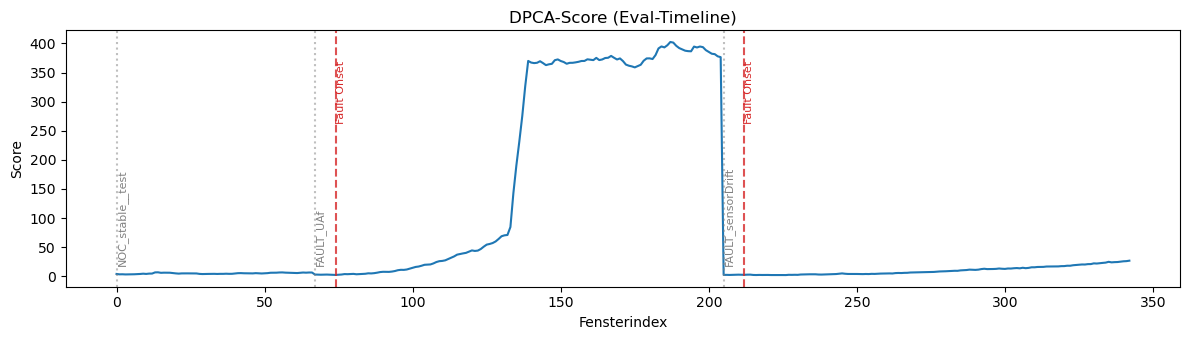

In [11]:
dpca_model = fit_dpca_model(
    Xtr,
    var_target=PCA_VAR_TARGET,
    min_components=MIN_PCA_COMPONENTS,
    max_components=MAX_PCA_COMPONENTS,
)
dpca_val = score_dpca_model(dpca_model, Xval)
dpca_noc_test = score_dpca_model(dpca_model, Xnoc_test)
dpca_eval = score_dpca_model(dpca_model, Xeval)

res_dpca = eval_scores(y_eval, dpca_eval, "DPCA")
score_store = {}
score_store["DPCA"] = {
    "val_noc": dpca_val,
    "noc_test": dpca_noc_test,
    "eval": dpca_eval,
}

print("DPCA-Komponenten:", dpca_model["n_components"], "| erklärte Varianz:", round(dpca_model["explained_variance_sum"], 4))
plot_score_timeline(dpca_eval, meta_eval, "DPCA-Score (Eval-Timeline)", ylabel="Score")

## (2) Canonical Variate Analysis (CVA)

Canonical Variate Analysis (CVA) modelliert die Dynamik eines Prozesses über die Beziehung zwischen
Vergangenheit und Zukunft. Dazu werden aus verzögerten Vergangenheits- und Zukunftsvektoren jene
Richtungen bestimmt, in denen beide Teile einer Zeitreihe möglichst stark korreliert sind.
CVA ist deshalb besonders interessant für dynamische Prozesse, bei denen nicht nur die momentane
Varianz, sondern vor allem die zeitliche Struktur des Verhaltens relevant ist.

Im FCCU-Notebook wird CVA als dynamischer Gegenpol zu DPCA verwendet. Die Methode wird auf
dem Normalbetrieb trainiert und erzeugt anschließend Residualscores für neue Fenster.
Diese Scores zeigen, ob die zukünftige Entwicklung eines Fensters noch zum erlernten dynamischen
Normalverhalten passt.

Eine gut passende Vergleichsquelle zu DPCA und CVA ist: https://web.mit.edu/braatzgroup/36_Fault_detection_in_industrial_processes_using_canonical_variate_analysis_and_dynamic_principal_component_analysis.pdf

CVA                      -> ROC-AUC=0.997 | AP=0.999
CVA-Komponenten: 198 | Energie: 0.9007


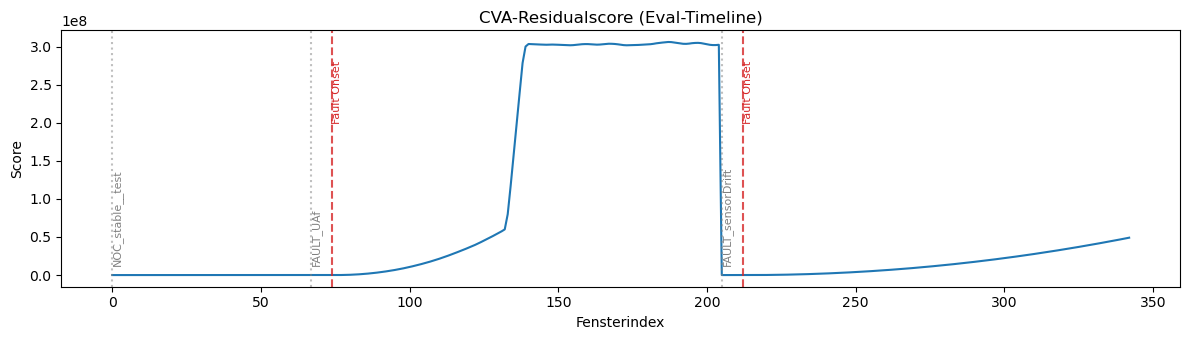

In [13]:
cva_model = fit_cva(
    raw_train_scaled,
    lags=CVA_LAGS,
    var_target=CVA_VAR_TARGET,
    min_components=MIN_CVA_COMPONENTS,
    max_components=MAX_CVA_COMPONENTS,
)

cva_val = cva_scores_for_meta(cva_model, raw_val_scaled, meta_noc_val, agg=CVA_WINDOW_AGG)
cva_noc_test = cva_scores_for_meta(cva_model, raw_test_scaled, meta_noc_test, agg=CVA_WINDOW_AGG)
cva_fault_eval = cva_scores_for_meta(cva_model, raw_fault_scaled, meta_fault_eval, agg=CVA_WINDOW_AGG)
cva_eval = np.concatenate([cva_noc_test, cva_fault_eval])

res_cva = eval_scores(y_eval, cva_eval, "CVA")
score_store["CVA"] = {
    "val_noc": cva_val,
    "noc_test": cva_noc_test,
    "eval": cva_eval,
}

print("CVA-Komponenten:", cva_model["n_components"], "| Energie:", round(cva_model["energy"], 4))
plot_score_timeline(cva_eval, meta_eval, "CVA-Residualscore (Eval-Timeline)", ylabel="Score")

## (3–5) Klassische Novelty Detection: Isolation Forest, One-Class SVM, LOF

Diese Verfahren werden auf den NOC-Trainfenstern gelernt und danach auf neue Fenster angewendet.
LOF bleibt im <code>novelty=True</code>-Modus erhalten, damit die Logik zur Novelty Detection passt.

Isolation Forest         -> ROC-AUC=0.456 | AP=0.720
One-Class SVM            -> ROC-AUC=0.732 | AP=0.922
LOF                      -> ROC-AUC=0.737 | AP=0.924


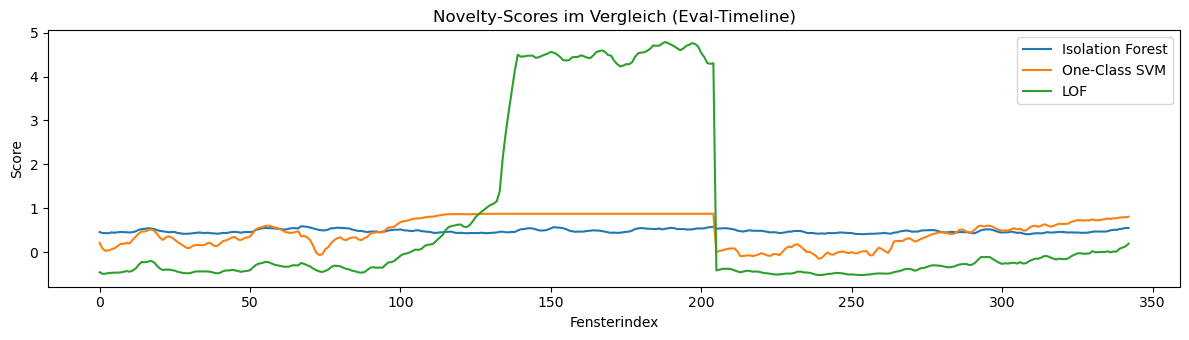

In [15]:
oneclass_models = fit_oneclass_models(Xtr)
scores_oneclass = score_oneclass_models(oneclass_models, Xeval)
scores_oneclass_val = score_oneclass_models(oneclass_models, Xval)
scores_oneclass_noc_test = score_oneclass_models(oneclass_models, Xnoc_test)

res_oneclass = {}
for key, arr in scores_oneclass.items():
    nice_name = {"isoforest": "Isolation Forest", "ocsvm": "One-Class SVM", "lof": "LOF"}[key]
    res_oneclass[key] = eval_scores(y_eval, arr, nice_name)
    score_store[nice_name] = {
        "val_noc": scores_oneclass_val[key],
        "noc_test": scores_oneclass_noc_test[key],
        "eval": arr,
    }

plt.figure(figsize=(12, 3.5))
plt.plot(scores_oneclass["isoforest"], label="Isolation Forest")
plt.plot(scores_oneclass["ocsvm"], label="One-Class SVM")
plt.plot(scores_oneclass["lof"], label="LOF")
plt.title("Novelty-Scores im Vergleich (Eval-Timeline)")
plt.xlabel("Fensterindex")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## (6) Shallow Autoencoder

Der flache Autoencoder dient hier als Ausblick und als erster Test eines rekonstruktionsbasierten
Deep-Learning-Modells im Vergleich zu den klassischen ML- und Statistik-Baselines.
Die Deep-Learning-Modelle selbst werden dann im nächsten Notebook ausführlicher betrachtet.

C:\Users\eichhorn\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Shallow Autoencoder      -> ROC-AUC=0.871 | AP=0.966


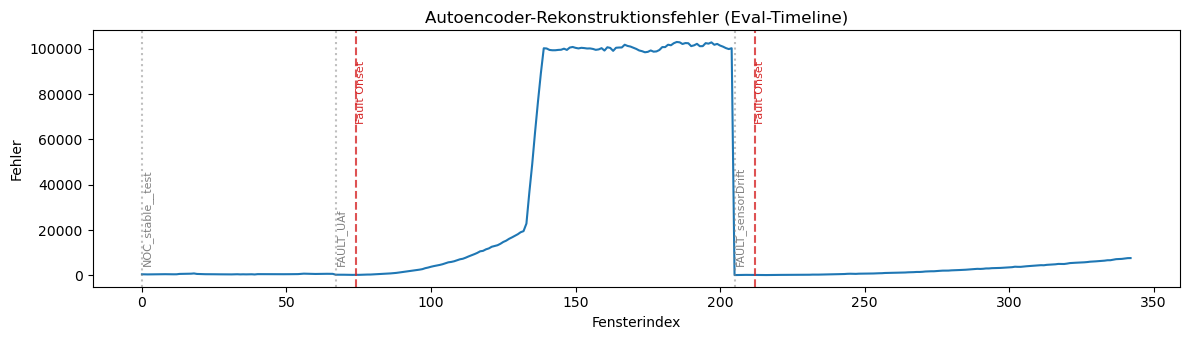

In [33]:
ae_model = fit_shallow_autoencoder(Xtr, hidden_ratio=0.5, max_iter=50)
ae_val = score_shallow_autoencoder(ae_model, Xval)
ae_noc_test = score_shallow_autoencoder(ae_model, Xnoc_test)
ae_eval = score_shallow_autoencoder(ae_model, Xeval)

res_ae = eval_scores(y_eval, ae_eval, "Shallow Autoencoder")
score_store["Shallow Autoencoder"] = {
    "val_noc": ae_val,
    "noc_test": ae_noc_test,
    "eval": ae_eval,
}

plot_score_timeline(ae_eval, meta_eval, "Autoencoder-Rekonstruktionsfehler (Eval-Timeline)", ylabel="Fehler")

## Bewertungsmetriken in der Übersicht

Die folgende Tabelle fasst die globalen Gütemaße der aktuell aktiven Modelle zusammen.
Für die eigentliche Betriebsbewertung sind später vor allem False Alarm Rate, First Alarm
und Detektionsverzögerung wichtig.

In [36]:
rows = []

def _append_metric(name: str, result: dict):
    if result is None:
        return
    rows.append({
        "Modell": name,
        "ROC-AUC": result.get("roc_auc", np.nan),
        "AP": result.get("ap", np.nan),
    })

_append_metric("DPCA", globals().get("res_dpca"))
_append_metric("CVA", globals().get("res_cva"))
_append_metric("Isolation Forest", res_oneclass.get("isoforest") if "res_oneclass" in globals() else None)
_append_metric("One-Class SVM", res_oneclass.get("ocsvm") if "res_oneclass" in globals() else None)
_append_metric("LOF", res_oneclass.get("lof") if "res_oneclass" in globals() else None)
_append_metric("Shallow Autoencoder", globals().get("res_ae"))

df_metrics = pd.DataFrame(rows).sort_values("Modell").reset_index(drop=True)
display(df_metrics)

,Modell,ROC-AUC,AP
0,CVA,0.996843,0.999223
1,DPCA,0.803930,0.945821
2,Isolation Forest,0.456083,0.720343
3,LOF,0.737348,0.923579
4,One-Class SVM,0.731505,0.921769
5,Shallow Autoencoder,0.871454,0.966360


## Schwellenkalibrierung, pointwise FAR und Alarmauswertung

<div style="border-left: 4px solid #A6A6A6; background:#FAFAFA; padding:10px 12px; margin:8px 0;">
<b>Merksatz</b><br>
Die Schwelle wird ausschließlich auf den gesunden Validierungsdaten kalibriert. Dabei wird die punktweise
False Alarm Rate ohne Persistence-Regel verwendet. Danach wird dieselbe Schwelle auf die gesunden Testdaten
angewendet und dort ebenfalls als punktweise FAR ausgewertet. Erst für die eigentliche Alarmbewertung auf
Testdaten und Fault-Sequenzen wird zusätzlich die Persistence-Regel verwendet.
</div>

In [39]:
# ------------------------------------------------------------
# Schwellenkalibrierung, pointwise FAR und Alarmbericht
# ------------------------------------------------------------
def far_threshold(noc_scores: np.ndarray, target_far: float = 0.01) -> float:
    noc_scores = np.asarray(noc_scores, dtype=float)
    noc_scores = noc_scores[np.isfinite(noc_scores)]
    if noc_scores.size == 0:
        return np.nan
    q = np.clip(1.0 - float(target_far), 0.0, 1.0)
    return float(np.quantile(noc_scores, q))


def pointwise_far(scores: np.ndarray, threshold: float) -> float:
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]
    if scores.size == 0:
        return np.nan
    return float(np.mean(scores > threshold))


def alarm_series(scores: np.ndarray, thr: float, persistence: int = 1) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    hits = scores >= thr
    alarm = np.zeros(len(scores), dtype=bool)
    run = 0
    for i, h in enumerate(hits):
        run = run + 1 if h else 0
        if run >= persistence:
            alarm[i] = True
    return alarm


def count_alarm_episodes(alarm: np.ndarray) -> int:
    alarm = np.asarray(alarm, dtype=bool)
    if alarm.size == 0:
        return 0
    return int(np.sum((alarm.astype(int)[1:] == 1) & (alarm.astype(int)[:-1] == 0))) + int(alarm[0])


def first_true_index(x: np.ndarray, start_idx: int = 0) -> int:
    x = np.asarray(x, dtype=bool)
    if start_idx >= len(x):
        return -1
    hits = np.where(x[start_idx:])[0]
    return int(start_idx + hits[0]) if hits.size > 0 else -1


def windows_to_hours(n_windows: int) -> float:
    return (n_windows * HOP * SAMPLE_TIME_MINUTES) / 60.0


def collect_fault_segments(meta_df: pd.DataFrame) -> List[dict]:
    segments = []
    fault_meta = meta_df[meta_df["is_fault_sequence"] == 1].copy()
    for source, block in fault_meta.groupby("source", sort=False):
        block = block.sort_values("global_idx")
        onset_rows = block[block["post_onset"] == 1]
        onset_global = int(onset_rows["global_idx"].iloc[0]) if len(onset_rows) > 0 else None
        segments.append({
            "source": source,
            "start_global": int(block["global_idx"].min()),
            "end_global": int(block["global_idx"].max()) + 1,
            "onset_global": onset_global,
        })
    return segments


def plot_val_test_threshold_diagnostics(model_name, val_scores, noc_test_scores, thr, target_far):
    val_scores = np.asarray(val_scores, dtype=float)
    noc_test_scores = np.asarray(noc_test_scores, dtype=float)

    val_far = pointwise_far(val_scores, thr)
    test_far = pointwise_far(noc_test_scores, thr)

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

    # Validierung
    axes[0].plot(np.arange(len(val_scores)), val_scores, label="NOC-Validierung")
    axes[0].axhline(thr, color="C1", linestyle="--", alpha=0.9, label=f"Schwelle @ FAR={target_far:.4f}")
    axes[0].set_title(f"{model_name} – Validierung | pointwise FAR = {val_far:.4f}")
    axes[0].set_xlabel("Fensterindex")
    axes[0].set_ylabel("Score")
    axes[0].legend()

    # NOC-Test
    axes[1].plot(np.arange(len(noc_test_scores)), noc_test_scores, label="NOC-Test")
    axes[1].axhline(thr, color="C1", linestyle="--", alpha=0.9, label=f"Schwelle @ FAR={target_far:.4f}")
    axes[1].set_title(f"{model_name} – NOC-Test | pointwise FAR = {test_far:.4f}")
    axes[1].set_xlabel("Fensterindex")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def threshold_and_alarm_report(
    target_far: float = 0.001,
    persistence: int = 3,
    plot_each: bool = True,
    plot_val_test_diag: bool = True,
):
    if "score_store" not in globals():
        raise RuntimeError("Es wurden noch keine Modell-Scores registriert.")

    fault_segments = collect_fault_segments(meta_eval)

    overall_rows = []
    segment_rows = []

    for model_name, parts in score_store.items():
        val_scores = np.asarray(parts["val_noc"], dtype=float)
        noc_test_scores = np.asarray(parts["noc_test"], dtype=float)
        eval_scores_arr = np.asarray(parts["eval"], dtype=float)

        # --------------------------------------------------------
        # 1) Schwelle auf Validierungs-NOC kalibrieren
        #    -> punktweise FAR ohne Persistence
        # --------------------------------------------------------
        thr = far_threshold(val_scores, target_far=target_far)

        pointwise_far_val = pointwise_far(val_scores, thr)
        pointwise_far_test = pointwise_far(noc_test_scores, thr)

        if plot_val_test_diag:
            plot_val_test_threshold_diagnostics(
                model_name=model_name,
                val_scores=val_scores,
                noc_test_scores=noc_test_scores,
                thr=thr,
                target_far=target_far,
            )

        # --------------------------------------------------------
        # 2) Alarmmanagement auf NOC-Test mit Persistence
        # --------------------------------------------------------
        noc_alarm = alarm_series(noc_test_scores, thr, persistence=persistence)
        noc_alarm_episodes = count_alarm_episodes(noc_alarm)
        noc_hours = windows_to_hours(len(noc_test_scores))
        false_alarms_per_hour = noc_alarm_episodes / noc_hours if noc_hours > 0 else np.nan
        alarm_window_share = float(np.mean(noc_alarm)) if len(noc_alarm) > 0 else np.nan

        # --------------------------------------------------------
        # 3) Alarmmanagement auf Eval-Daten (NOC-Test + Faults)
        # --------------------------------------------------------
        first_fault_onset_global = None
        if fault_segments:
            valid_onsets = [seg["onset_global"] for seg in fault_segments if seg["onset_global"] is not None]
            if valid_onsets:
                first_fault_onset_global = int(min(valid_onsets))

        full_alarm = alarm_series(eval_scores_arr, thr, persistence=persistence)

        start_global = first_fault_onset_global if first_fault_onset_global is not None else len(meta_noc_test)
        alarm_after_onset = full_alarm.copy()
        alarm_after_onset[:start_global] = False

        hits_global = np.where(alarm_after_onset)[0]
        first_alarm_idx = int(hits_global[0]) if hits_global.size > 0 else -1
        delay_global = (first_alarm_idx - first_fault_onset_global) if (first_alarm_idx >= 0 and first_fault_onset_global is not None) else np.nan

        overall_rows.append({
            "Modell": model_name,
            "Schwelle": thr,
            "Pointwise FAR (NOC-Val)": pointwise_far_val,
            "Pointwise FAR (NOC-Test)": pointwise_far_test,
            "False alarms / h (NOC-Test)": false_alarms_per_hour,
            "Alarmanteil (NOC-Test)": alarm_window_share,
            "Alarmepisoden (NOC-Test)": noc_alarm_episodes,
            "First alarm idx": (first_alarm_idx if first_alarm_idx >= 0 else np.nan),
            "Detektionsverzögerung (Fenster)": delay_global,
            "Detektionsverzögerung (min)": (delay_global * HOP * SAMPLE_TIME_MINUTES if np.isfinite(delay_global) else np.nan),
        })

        # --------------------------------------------------------
        # 4) Fault-spezifische Auswertung
        # --------------------------------------------------------
        for seg in fault_segments:
            start_idx = seg["onset_global"] if seg["onset_global"] is not None else seg["start_global"]
            seg_alarm_mask = full_alarm.copy()
            seg_alarm_mask[:start_idx] = False
            hits = np.where(seg_alarm_mask)[0]
            seg_alarm_idx = int(hits[0]) if hits.size > 0 else -1
            if seg_alarm_idx >= seg["end_global"]:
                seg_alarm_idx = -1
            seg_delay = (seg_alarm_idx - start_idx) if seg_alarm_idx >= 0 else np.nan

            segment_rows.append({
                "Modell": model_name,
                "Fault": seg["source"],
                "Onset idx": start_idx,
                "First alarm idx": (seg_alarm_idx if seg_alarm_idx >= 0 else np.nan),
                "Detektionsverzögerung (Fenster)": seg_delay,
                "Detektionsverzögerung (min)": (seg_delay * HOP * SAMPLE_TIME_MINUTES if np.isfinite(seg_delay) else np.nan),
                "Schwelle": thr,
            })

        # --------------------------------------------------------
        # 5) Pro-Modell-Plot für Eval-Timeline
        # --------------------------------------------------------
        if plot_each:
            fig = plt.figure(figsize=(12, 4))
            ax = plt.gca()
            xs = np.arange(len(eval_scores_arr))
            ax.plot(xs, eval_scores_arr, label=f"{model_name} – Score")
            ax.axhline(thr, color="C1", linestyle="--", alpha=0.9, label=f"Schwelle @ FAR={target_far:.4f}")

            for source, block in meta_eval.groupby("source", sort=False):
                x0 = int(block["global_idx"].min())
                ax.axvline(x0, color="gray", linestyle=":", alpha=0.5)
                ax.text(
                    x0,
                    np.nanmin(eval_scores_arr) + 0.04 * (np.nanmax(eval_scores_arr) - np.nanmin(eval_scores_arr) + 1e-9),
                    str(source),
                    rotation=90,
                    va="bottom",
                    ha="left",
                    fontsize=8,
                    color="gray",
                )

            for seg in fault_segments:
                if seg["onset_global"] is not None:
                    ax.axvline(seg["onset_global"], color="C3", linestyle="--", alpha=0.7)

            if first_alarm_idx >= 0:
                ax.axvline(first_alarm_idx, color="C2", linestyle="-", alpha=0.9, label="First persistent alarm")

            ax.set_title(f"{model_name}: Score, Schwelle und Fault Onset")
            ax.set_xlabel("Fensterindex")
            ax.set_ylabel("Score")
            ax.legend()
            plt.tight_layout()
            plt.show()

    df_overall = pd.DataFrame(overall_rows).sort_values("Modell").reset_index(drop=True)
    df_segments = pd.DataFrame(segment_rows).sort_values(["Modell", "Fault"]).reset_index(drop=True)

    display(df_overall)
    display(df_segments)

    order = df_overall["Modell"].tolist()
    x = np.arange(len(order))

    # Balkendiagramm Detektionsverzögerung
    plt.figure(figsize=(10, 4))
    vals = df_overall.set_index("Modell").loc[order]["Detektionsverzögerung (Fenster)"].values.astype(float)
    bars = plt.bar(x, np.nan_to_num(vals, nan=0.0))
    for i, v in enumerate(vals):
        txt = "NaN" if np.isnan(v) else f"{int(v)}"
        plt.text(i, 0.01 if np.isnan(v) else v, txt, ha="center", va="bottom", fontsize=9)
        if np.isnan(v):
            bars[i].set_alpha(0.3)
            bars[i].set_hatch("//")
    plt.xticks(x, order, rotation=20, ha="right")
    plt.ylabel("Detektionsverzögerung (Fenster)")
    plt.title("Detektionsverzögerung pro Modell")
    plt.tight_layout()
    plt.show()

    # Balkendiagramm First Alarm
    plt.figure(figsize=(10, 4))
    vals2 = df_overall.set_index("Modell").loc[order]["First alarm idx"].values.astype(float)
    bars2 = plt.bar(x, np.nan_to_num(vals2, nan=0.0))
    for i, v in enumerate(vals2):
        txt = "NaN" if np.isnan(v) else f"{int(v)}"
        plt.text(i, 0.01 if np.isnan(v) else v, txt, ha="center", va="bottom", fontsize=9)
        if np.isnan(v):
            bars2[i].set_alpha(0.3)
            bars2[i].set_hatch("//")
    plt.xticks(x, order, rotation=20, ha="right")
    plt.ylabel("First alarm idx")
    plt.title("Erster persistenter Alarm pro Modell")
    plt.tight_layout()
    plt.show()

    return df_overall, df_segments

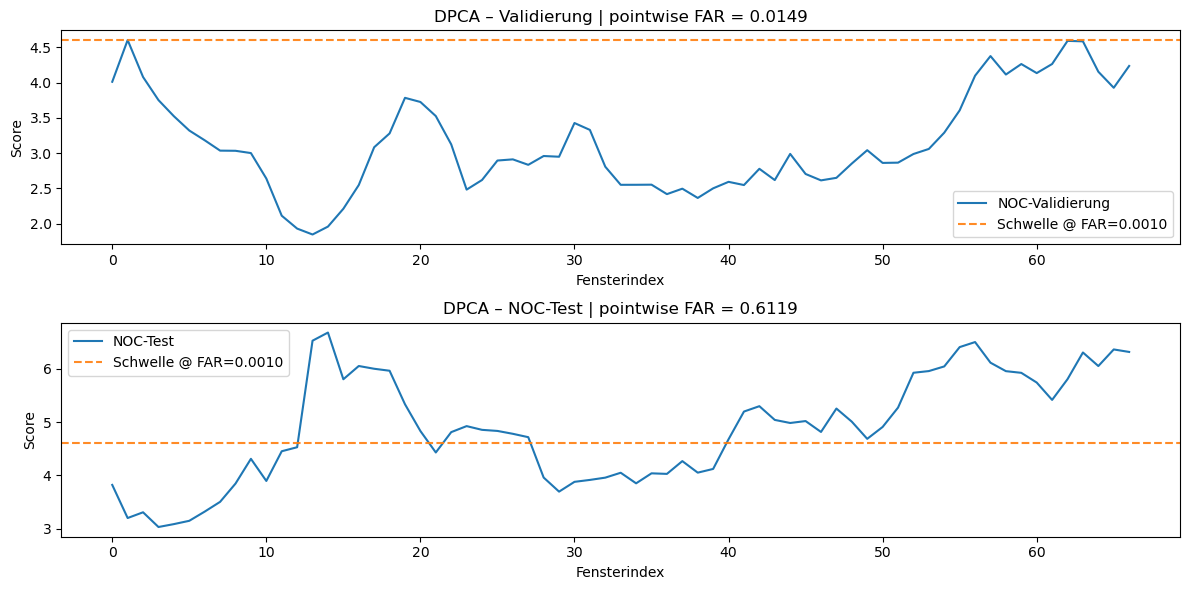

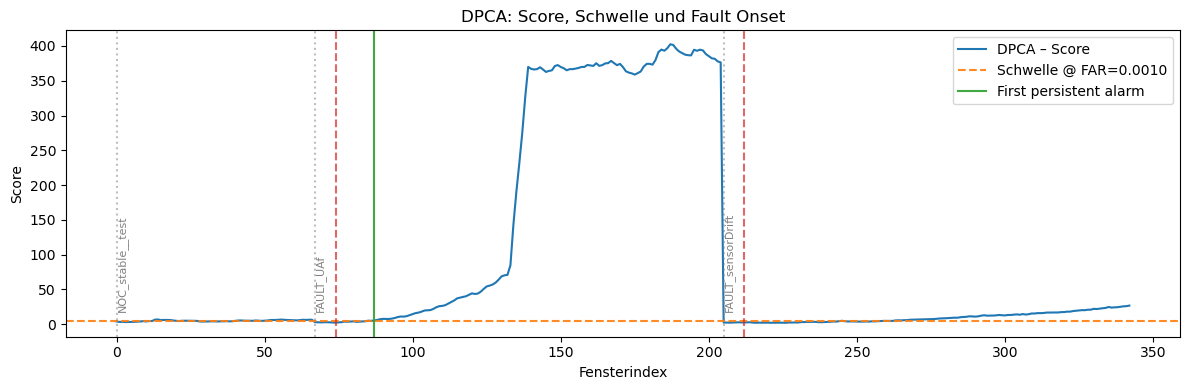

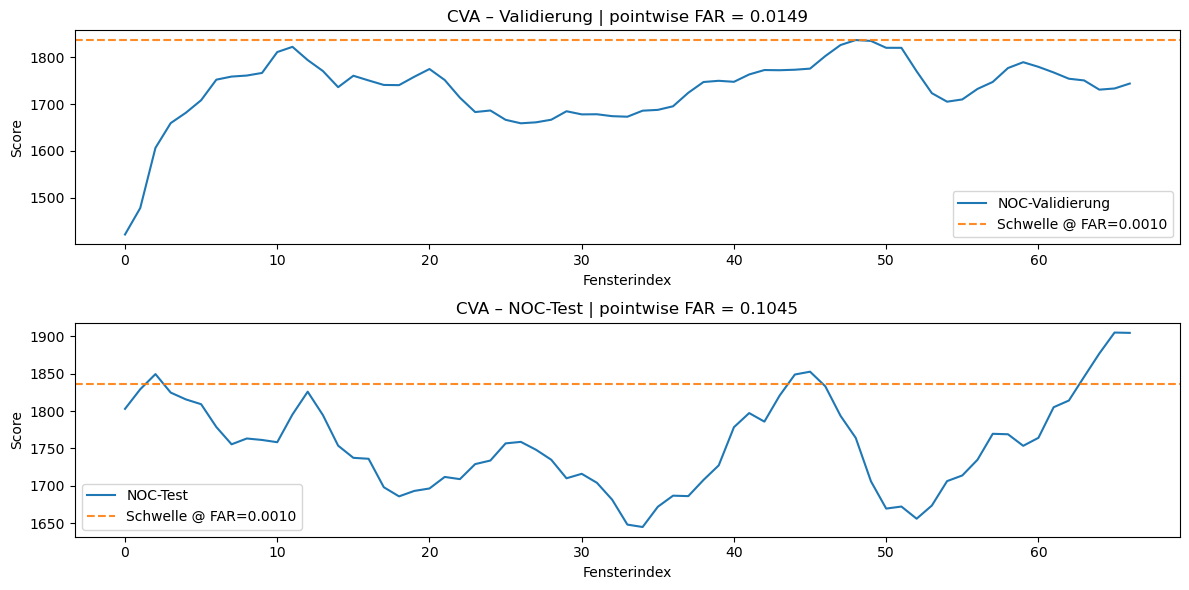

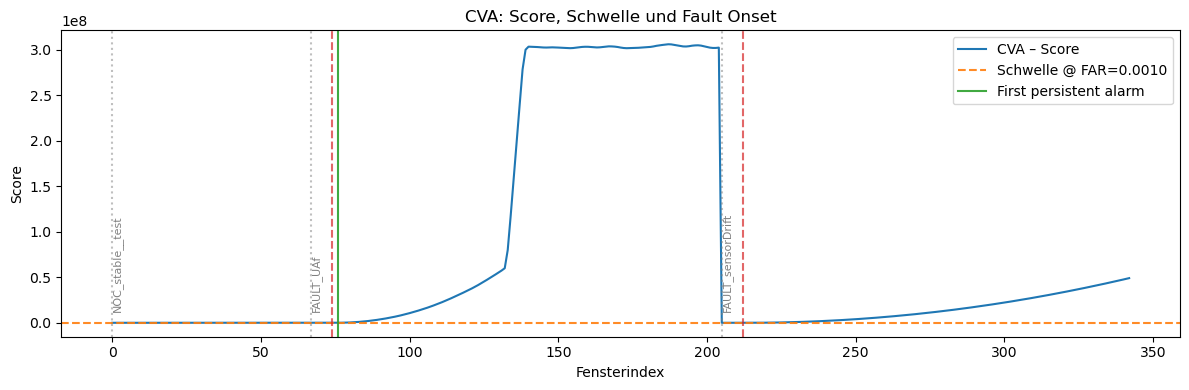

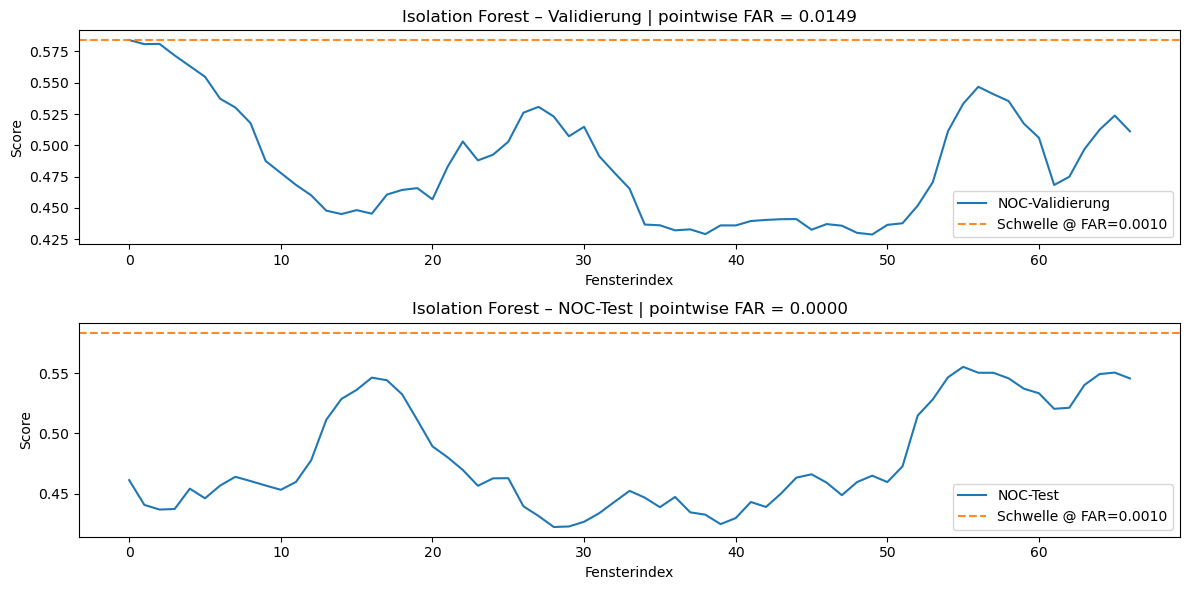

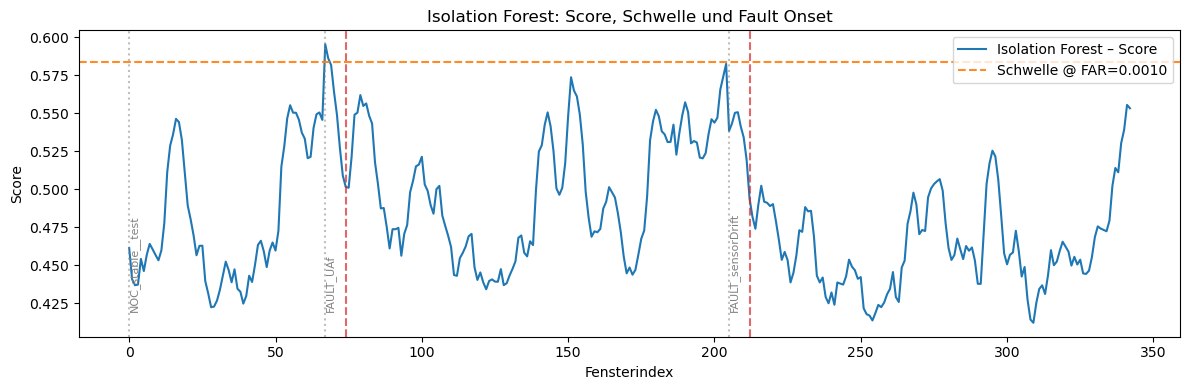

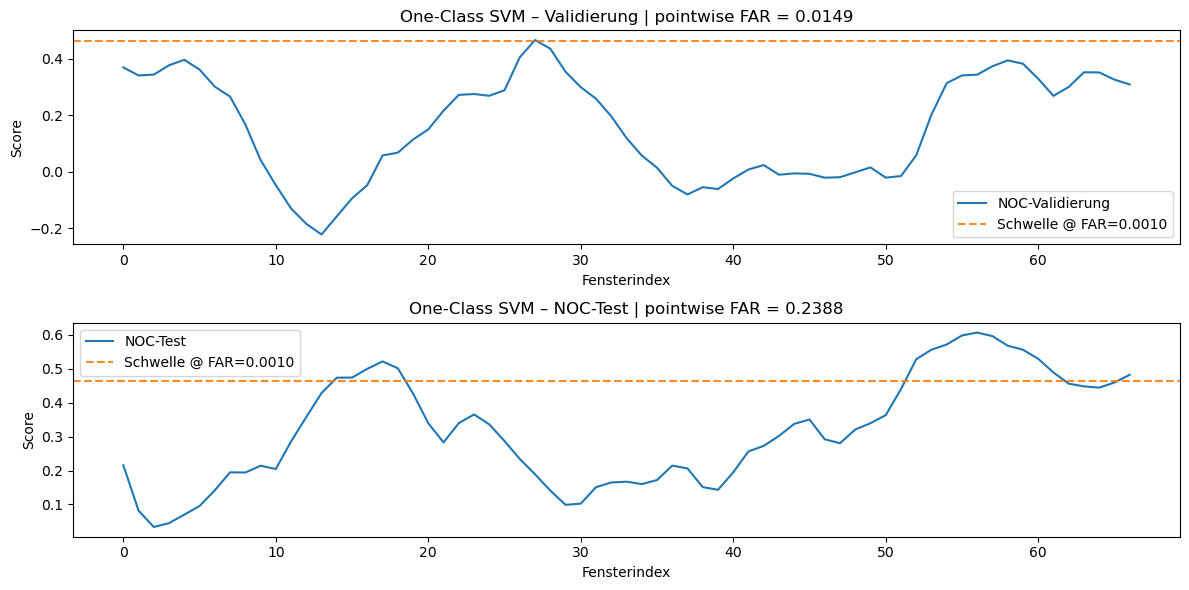

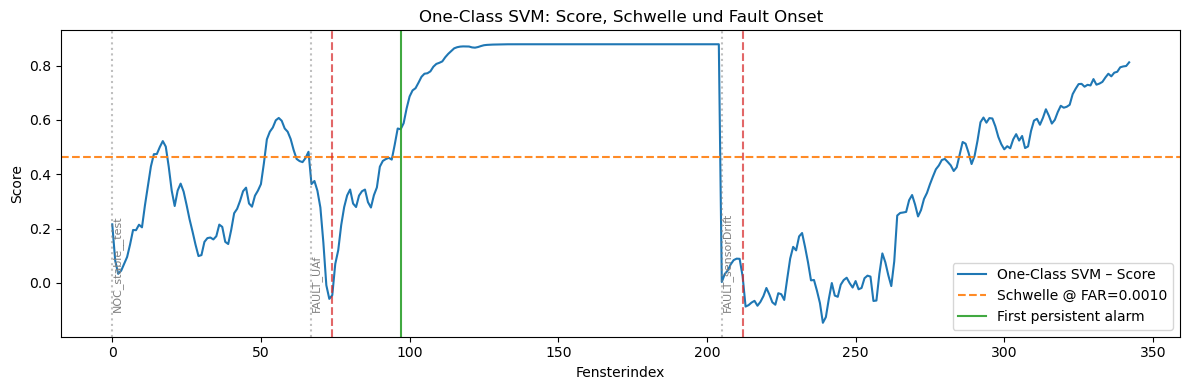

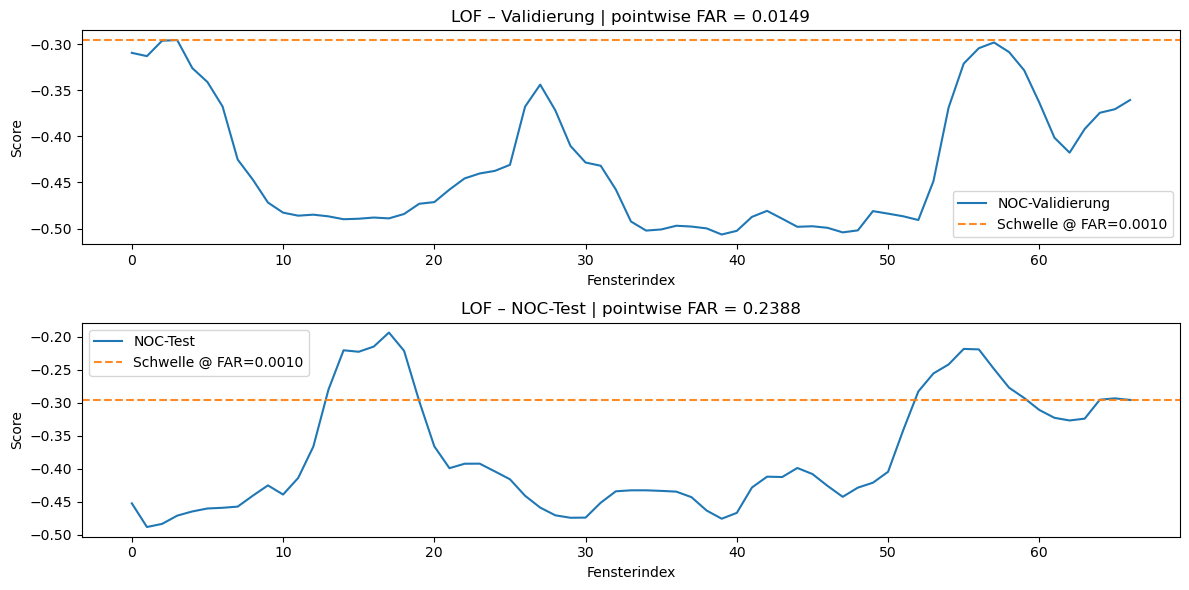

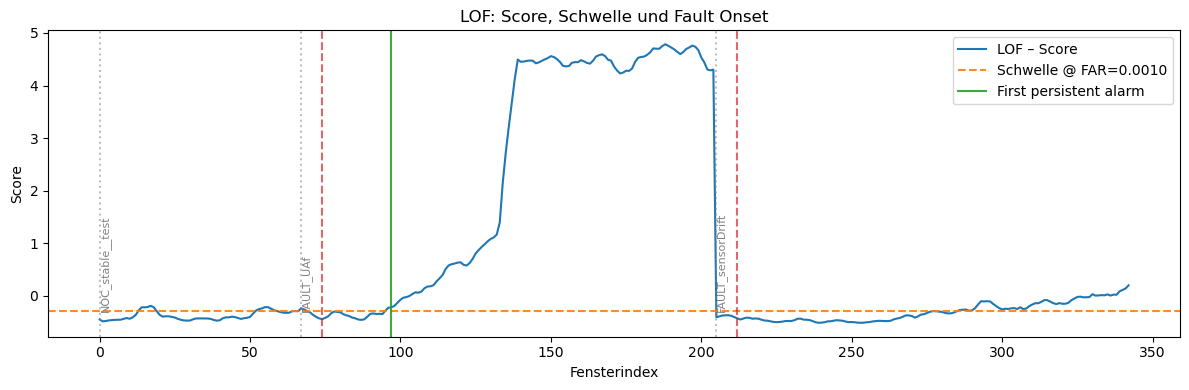

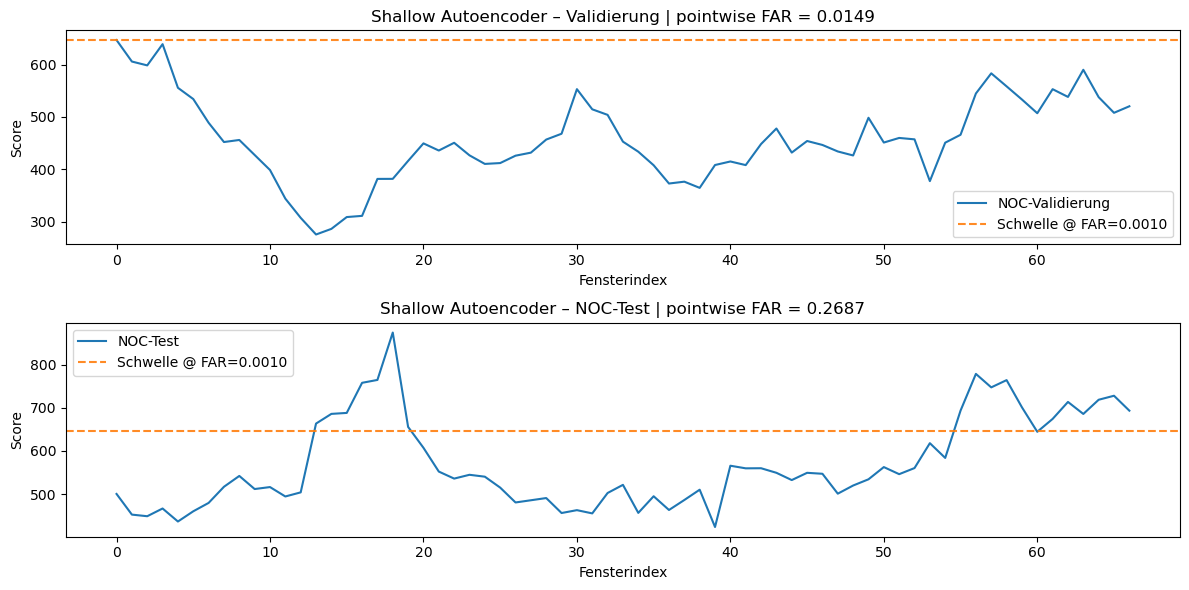

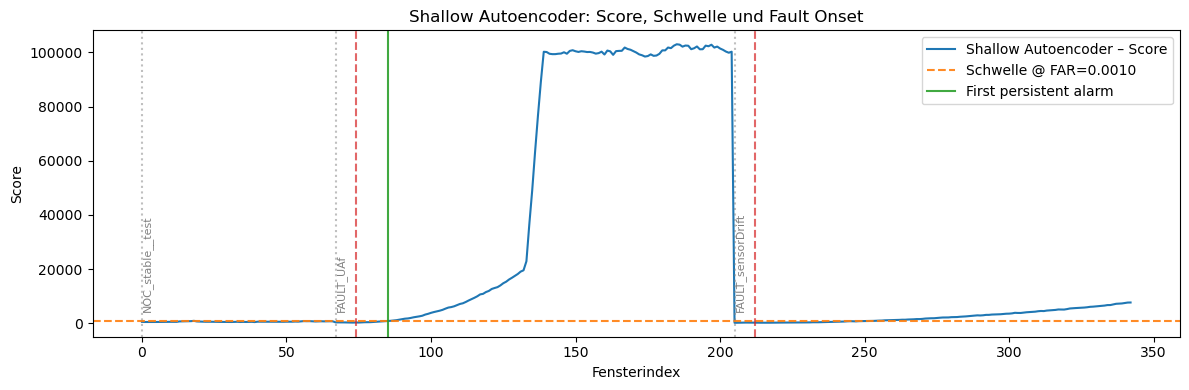

,Modell,Schwelle,Pointwise FAR (NOC-Val),Pointwise FAR (NOC-Test),False alarms / h (NOC-Test),Alarmanteil (NOC-Test),Alarmepisoden (NOC-Test),First alarm idx,Detektionsverzögerung (Fenster),Detektionsverzögerung (min)
0,CVA,1836.379413,0.014925,0.104478,0.089552,0.029851,1,76.0,2.0,20.0
1,DPCA,4.603494,0.014925,0.611940,0.268657,0.522388,3,87.0,13.0,130.0
2,Isolation Forest,0.583825,0.014925,0.000000,0.000000,0.000000,0,NaN,NaN,NaN
3,LOF,-0.295468,0.014925,0.238806,0.179104,0.149254,2,97.0,23.0,230.0
4,One-Class SVM,0.464803,0.014925,0.238806,0.179104,0.164179,2,97.0,23.0,230.0
5,Shallow Autoencoder,646.100591,0.014925,0.268657,0.268657,0.179104,3,85.0,11.0,110.0


,Modell,Fault,Onset idx,First alarm idx,Detektionsverzögerung (Fenster),Detektionsverzögerung (min),Schwelle
0,CVA,FAULT_UAf,74,76.0,2.0,20.0,1836.379413
1,CVA,FAULT_sensorDrift,212,215.0,3.0,30.0,1836.379413
2,DPCA,FAULT_UAf,74,87.0,13.0,130.0,4.603494
3,DPCA,FAULT_sensorDrift,212,261.0,49.0,490.0,4.603494
4,Isolation Forest,FAULT_UAf,74,NaN,NaN,NaN,0.583825
5,Isolation Forest,FAULT_sensorDrift,212,NaN,NaN,NaN,0.583825
6,LOF,FAULT_UAf,74,97.0,23.0,230.0,-0.295468
7,LOF,FAULT_sensorDrift,212,287.0,75.0,750.0,-0.295468
8,One-Class SVM,FAULT_UAf,74,97.0,23.0,230.0,0.464803
9,One-Class SVM,FAULT_sensorDrift,212,287.0,75.0,750.0,0.464803


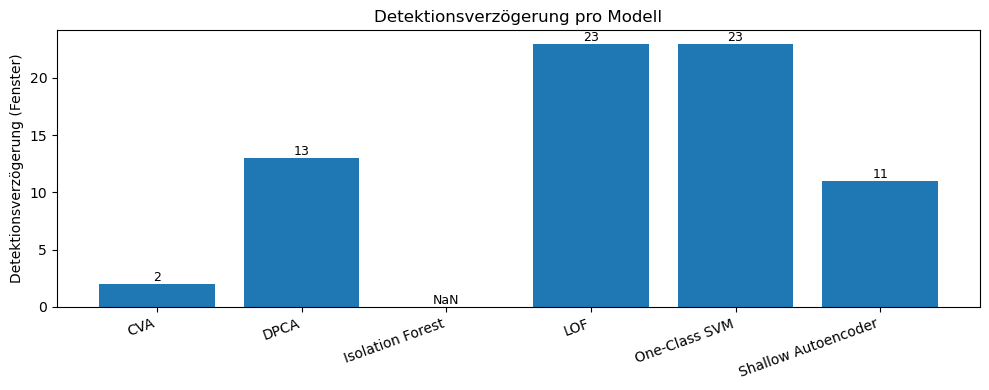

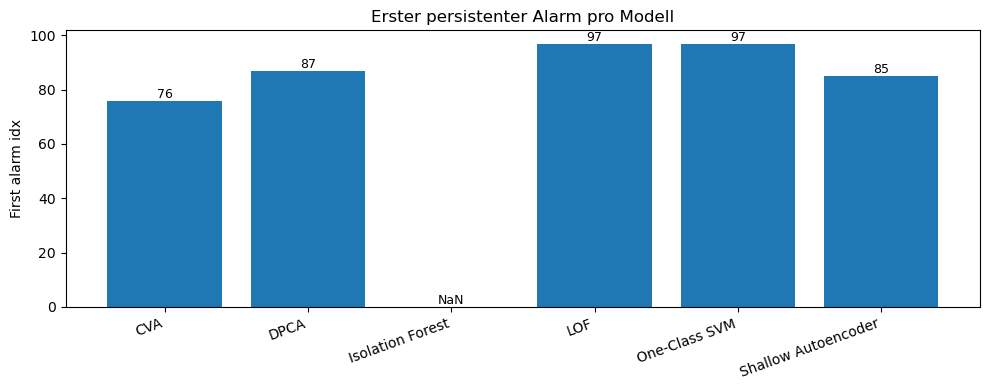

In [41]:
df_thr_alarm, df_thr_alarm_faults = threshold_and_alarm_report(
    target_far=TARGET_FAR,
    persistence=PERSISTENCE,
    plot_each=True,
# ausblenden der Visualisierung:
    #plot_val_test_diag=False,
)

